# Immunogenicity tool test: Testing setttings for tools: BioPhi(OASis): Tool outputs
Author: Rebecka Antonsson\
Version: 1 (25-02-2026)


# Notebook explanation
Notebook to calculate the scores of the outputs from the tool BioPhi(OASis) with different settings.

Settings tested are:

NrKab_CDRKAB_Loose\
NrKab_CDRKAB_Relaxed\
NrKab_CDRKAB_Medium\
NrKab_CDRKAB_Strict\
\
NrKab_CDRChot_Relaxed\
NrKab_CDRIMGT_Relaxed\
NrKab_CDRNorth_Relaxed\
\
NrChot_CDRKab_Relaxed\
NrIMGT_CDRKab_Relaxed\
NrAHo_CDRKab_Relaxed\
\
NrKAB_CDRChot_Strict\   
NrKAB_CDRIMGT_Strict\ 
NrKAB_CDRNorth_Strict\ 
\
NrKAB_CDRChot_Loose\
NrKAB_CDRIMGT_Loose\
NrKAB_CDRNorth_Loose\
\
NrChot_CDRKAB_Strict\
NrIMGT_CDRKAB_Strict\
NrAHo_CDRKAB_Strict\

Nr stands for ANARCI numbering scheme used to align sequences and annotate position numbers. It has the options Kabat, Chothia, IMGT and AHo
CDR stands for CDR Definition, and is the scheme used to define the CDR regions. It has the options: Kabat, Chothia, IMGT and North

The prediction is performed on 37 antibodies and 2 nanobodies. 

The purpose of this script is to rank the 39 antibodies/nanobodies and for each setting rank them according to their OASis Identity score.
The OASis Identity score is the percantage of peptides that are considerd human. Dependent on the last setting (loose, relaxed, medium or strict). It is the percantage of peptides that are found in at least 1%, 10%, 50% or 90% (respectivly) of human subjects in their data base. A higher OASis Identity score means that the antibody/nanobody is supposed to be less immunogenetic.

For each tool_output with different settings a ranking from 1 to 37 will be done, each antibody will hence be given a number 1 to 37
This ranking will be compared to the known/ clinically determined immunigenecity ranking of the antibodies. The clinical immunigenecity ranking is based on anti-drug antibody (ADA) data. The two nanobodies will be held outside the ranking since they have risk of behaving differently, and special intreset is taken in how the tool perform at prediction those.

For each setting three measurments on how good they perform will be calculated:
    1. Mean absolute rank error (MARE) for antibodies
    2. Spearman rank correlation
    3. Mean absolute rank error for the two nanobodies

1. MARE is just the absolute difference between the known rank of the antibody and the predicted rank
2. Spearman rank correlation is a statistical test that can compare two lists of ranking and tell how well they align. 1 is a perfect correlation
0 means no relation between the two variables (no correlation, random) and -1 is a perfect reversed correlation (very bad).
3. Same calculation as for 1, but separated from the rest. Here a separate ranking where the 2 nanobodies are included are performed, hence antobodies and nanobodies get a number 1 to 39 and the MARE for the nanobodies is calculated. 

In [20]:
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [2]:
# Load the tool outputs with the different setttings, store each in a separate pandas DataFrame
NrKab_CDRKab_Loose = pd.read_excel("tool_outputs/NrKab_CDRKab_Loose_2026-02-25.xlsx")
NrKab_CDRKab_Relaxed = pd.read_excel("tool_outputs/NRKab_CDRKab_Relaxed_2026-02-25.xlsx")
NrKab_CDRKab_Medium = pd.read_excel("tool_outputs/NrKab_CDRKab_Medium_2026-02-24.xlsx")
NrKab_CDRKab_Strict = pd.read_excel("tool_outputs/NrKAb_CDRKab_Strict_2026-02-25.xlsx")

NrKab_CDRChot_Relaxed = pd.read_excel("tool_outputs/NrKab_CDRChot_Relaxed_2026-02-25.xlsx")
NrKab_CDRIMGT_Relaxed = pd.read_excel("tool_outputs/NrKab_CDRIMGT_Relaxed_2026-02-25.xlsx")
NrKab_CDRNorth_Relaxed = pd.read_excel("tool_outputs/NrKAB_CDRNorth_Relaxed_2026-02-25.xlsx")

NrChot_CDRKab_Relaxed = pd.read_excel("tool_outputs/NrChot_CDRKAB_Relaxed_2026-02-25.xlsx")
NrIMGT_CDRKab_Relaxed = pd.read_excel("tool_outputs/NrIMGT_CDRKAB_Relaxed_2026-02-25.xlsx")
NrAHo_CDRKab_Relaxed = pd.read_excel("tool_outputs/NrAHo_CDRKAB_Relaxed_2026-02-25.xlsx")

NrKAB_CDRChot_Strict = pd.read_excel("tool_outputs/NrKAB_CDRChot_Strict_2026-02-26.xlsx")   
NrKAB_CDRIMGT_Strict = pd.read_excel("tool_outputs/NrKAB_CDRIMGT_Strict_2026-02-26.xlsx")   
NrKAB_CDRNorth_Strict = pd.read_excel("tool_outputs/NrKAB_CDRNorth_Strict_2026-02-26.xlsx")

NrKAB_CDRChot_Loose = pd.read_excel("tool_outputs/NrKAB_CDRChot_Loose_2026-02-26.xlsx") 
NrKAB_CDRIMGT_Loose = pd.read_excel("tool_outputs/NrKAB_CDRIMGT_Loose_2026-02-26.xlsx")
NrKAB_CDRNorth_Loose = pd.read_excel("tool_outputs/NrKAB_CDRNorth_Loose_2026-02-26.xlsx")

NrChot_CDRKAB_Strict = pd.read_excel("tool_outputs/NrChot_CDRKAB_Strict_2026-02-26.xlsx")   
NrIMGT_CDRKAB_Strict = pd.read_excel("tool_outputs/NrIMGT_CDRKAB_Strict_2026-02-26.xlsx")   
NrAHo_CDRKAB_Strict = pd.read_excel("tool_outputs/NrAHo_CDRKAB_Strict_2026-02-26.xlsx") 


In [3]:
# Print head to see that its loaded correctly
NrKab_CDRKab_Relaxed.head()

# print tail as well


,Antibody,Threshold,OASis Percentile,OASis Identity,Germline Content,Heavy V Germline,Heavy J Germline,Heavy OASis Percentile,Heavy OASis Identity,Heavy Non-human peptides,Heavy Germline Content,Light V Germline,Light J Germline,Light OASis Percentile,Light OASis Identity,Light Non-human peptides,Light Germline Content
0,ADALIMUMAB,relaxed,0.730717,0.896226,0.899123,IGHV3-9*01,IGHJ4*01,0.643319,0.831858,"(19,)",0.867769,IGKV1-27*01,IGKJ1*01,0.777576,0.969697,3.0,0.934579
1,ALEMTUZUMAB,relaxed,0.466755,0.773585,0.789474,IGHV4-30-4*01,IGHJ4*01,0.380027,0.725664,"(31,)",0.727273,IGKV1-33*01,IGKJ1*01,0.525162,0.828283,17.0,0.859813
2,ALIROCUMAB,relaxed,0.826651,0.934884,0.896104,IGHV3-23*04,IGHJ2*01,0.872545,0.918182,"(9,)",0.864407,IGKV4-1*01,IGKJ2*01,0.754095,0.952381,5.0,0.929204
3,BASILIXIMAB,relaxed,0.004000,0.390244,0.665158,IGHV1-3*01,IGHJ4*01,0.036000,0.412844,"(64,)",0.658120,IGKV3-11*01,IGKJ2*01,0.006833,0.364583,61.0,0.673077
4,BENRALIZUMAB,relaxed,0.218660,0.707547,0.802632,IGHV1-46*01,IGHJ4*01,0.158770,0.637168,"(41,)",0.743802,IGKV1-39*01,IGKJ1*01,0.412303,0.787879,21.0,0.869159


The tool BioPhi OASis takes input with the sequence for heavy and light chains as seperate inputs. For examle Antibody1_HC and Antibody1_LC. SO each antibody input is seperated in 2 sequences. THis works fine for the "normal" antibodies. However, one of the nanobodies consists of two heavy chains, and are named "Vobarilizumab_HC1" and "Vobarilizumab_HC2", which BioPhi OASis cant handle as one. Therefore BioPhi OASis outputs two rows fo this nanobody. Below the mean OASis Identity score is calcualted for Vobarilizumab, from the two rows and a new row witht he combined score is added. Only numneric mean is calculated, other values are ignored because they are not needed for further processing. This is done for al ten data frames. 

In [4]:
# Function that takes a dataframe as input, calculated the mean of all numeric values for Vobarilizumab_HC1 and Vobarilizumab_HC2, 
# adds a new row for Vobarilizumab with those values
def make_correct_Vobarilizumab_row(df):
    
    # Compute mean row
    mean_row = (
        df
        .query("Antibody in ['Vobarilizumab_HC1','Vobarilizumab_HC2']")
        .assign(Antibody="Vobarilizumab")
        .groupby("Antibody", as_index=False)
        .mean(numeric_only=True)
    )

    # Update the Vobarilizumab row with the mean OASis Identity value
    df = pd.concat([
        df.query("Antibody not in ['Vobarilizumab_HC1','Vobarilizumab_HC2']"),
        mean_row
    ], ignore_index=True)

    return df



In [5]:
# Create dictionary with all df names too loop through them
all_dfs = {
    "NrKab_CDRKab_Loose": NrKab_CDRKab_Loose,
    "NrKab_CDRKab_Relaxed": NrKab_CDRKab_Relaxed,
    "NrKab_CDRKab_Medium": NrKab_CDRKab_Medium,
    "NrKab_CDRKab_Strict": NrKab_CDRKab_Strict,
    "NrKab_CDRChot_Relaxed": NrKab_CDRChot_Relaxed,
    "NrKab_CDRIMGT_Relaxed": NrKab_CDRIMGT_Relaxed,
    "NrKab_CDRNorth_Relaxed": NrKab_CDRNorth_Relaxed, 
    "NrChot_CDRKab_Relaxed": NrChot_CDRKab_Relaxed,
    "NrIMGT_CDRKab_Relaxed": NrIMGT_CDRKab_Relaxed, 
    "NrAHo_CDRKab_Relaxed": NrAHo_CDRKab_Relaxed,
    "NrKAB_CDRChot_Strict": NrKAB_CDRChot_Strict,
    "NrKAB_CDRIMGT_Strict": NrKAB_CDRIMGT_Strict,
    "NrKAB_CDRNorth_Strict": NrKAB_CDRNorth_Strict,
    "NrKAB_CDRChot_Loose": NrKAB_CDRChot_Loose,
    "NrKAB_CDRIMGT_Loose": NrKAB_CDRIMGT_Loose,
    "NrKAB_CDRNorth_Loose": NrKAB_CDRNorth_Loose,
    "NrChot_CDRKAB_Strict": NrChot_CDRKAB_Strict,
    "NrIMGT_CDRKAB_Strict": NrIMGT_CDRKAB_Strict,
    "NrAHo_CDRKAB_Strict": NrAHo_CDRKAB_Strict
    }


# Loop through created list and send each dataframe to the function that makes the correct Vobarilizumab row
for name in all_dfs:
    all_dfs[name] = make_correct_Vobarilizumab_row(all_dfs[name])

# Check so it worked for one of the dataframes
all_dfs["NrKab_CDRKab_Loose"].tail()

,Antibody,Threshold,OASis Percentile,OASis Identity,Germline Content,Heavy V Germline,Heavy J Germline,Heavy OASis Percentile,Heavy OASis Identity,Heavy Non-human peptides,Heavy Germline Content,Light V Germline,Light J Germline,Light OASis Percentile,Light OASis Identity,Light Non-human peptides,Light Germline Content
34,TILDRAKIZUMAB,loose,0.393874,0.830918,0.825112,IGHV1-18*01,IGHJ4*01,0.432852,0.824074,"(19,)",0.801724,IGKV1-39*01,IGKJ1*01,0.319606,0.838384,16.0,0.850467
35,USTEKINUMAB,loose,0.705000,0.933333,0.902655,IGHV5-51*01,IGHJ4*01,0.585946,0.873874,"(14,)",0.840336,IGKV1D-16*01,IGKJ2*01,1.000000,1.000000,0.0,0.971963
36,VEDOLIZUMAB,loose,0.414249,0.834101,0.819742,IGHV1-3*01,IGHJ4*01,0.383867,0.805310,"(22,)",0.793388,IGKV2-40*01,IGKJ1*01,0.397077,0.865385,14.0,0.848214
37,VISILIZUMAB,loose,0.228714,0.795238,0.823009,IGHV1-46*04,IGHJ4*01,0.240000,0.758929,"(27,)",0.783333,IGKV1-39*01,IGKJ4*01,0.316143,0.836735,16.0,0.867925
38,Vobarilizumab,NaN,0.319814,0.793483,0.793209,NaN,NaN,0.369518,0.793483,NaN,0.793209,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Get number of rows, should be 39
for df in all_dfs.values():
    print(df.shape[0])

39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39
39


In [7]:
# Add column ranked_score, were all rows except "Caplacizumab" and "Vobarilizumab" 
# get a score from 1 to 37 based on the value in the column "OASis Identity"

# First add a column called ranked_by_tool to all dataframes, set all values to 0 for now
for df in all_dfs.values():
    df['ranked_by_tool'] = 0


# Make a copy of all dataframes and delete the rows for Caplacizumab and Vobarilizumab, a new dataframe with index _AB is created
# we need to do this because we don't want these two nanobodies to be ranked, 
# but we also don't want them to mess with the ranking of the other antibodies

all_dfs_AB = {}

for name, df in all_dfs.items():
    # make a new dictionary with a copy of the dataframes but without the two nanobodies
    all_dfs_AB[name + "_AB"] = df.loc[~df['Antibody'].isin(['Caplacizumab', 'Vobarilizumab'])].copy()

# Check so it worked
all_dfs_AB.keys()
all_dfs_AB["NrKab_CDRKab_Loose_AB"].tail()


,Antibody,Threshold,OASis Percentile,OASis Identity,Germline Content,Heavy V Germline,Heavy J Germline,Heavy OASis Percentile,Heavy OASis Identity,Heavy Non-human peptides,Heavy Germline Content,Light V Germline,Light J Germline,Light OASis Percentile,Light OASis Identity,Light Non-human peptides,Light Germline Content,ranked_by_tool
33,SECUKINUMAB,loose,0.839950,0.968037,0.906383,IGHV3-7*01,IGHJ2*01,0.807000,0.941176,"(7,)",0.850394,IGKV3-20*01,IGKJ2*02,1.000000,1.000000,0.0,0.972222,0
34,TILDRAKIZUMAB,loose,0.393874,0.830918,0.825112,IGHV1-18*01,IGHJ4*01,0.432852,0.824074,"(19,)",0.801724,IGKV1-39*01,IGKJ1*01,0.319606,0.838384,16.0,0.850467,0
35,USTEKINUMAB,loose,0.705000,0.933333,0.902655,IGHV5-51*01,IGHJ4*01,0.585946,0.873874,"(14,)",0.840336,IGKV1D-16*01,IGKJ2*01,1.000000,1.000000,0.0,0.971963,0
36,VEDOLIZUMAB,loose,0.414249,0.834101,0.819742,IGHV1-3*01,IGHJ4*01,0.383867,0.805310,"(22,)",0.793388,IGKV2-40*01,IGKJ1*01,0.397077,0.865385,14.0,0.848214,0
37,VISILIZUMAB,loose,0.228714,0.795238,0.823009,IGHV1-46*04,IGHJ4*01,0.240000,0.758929,"(27,)",0.783333,IGKV1-39*01,IGKJ4*01,0.316143,0.836735,16.0,0.867925,0


In [8]:


# Rank the new AB data frames  based on the OASis Identity column 

# Ascending False, gives rank 1 to the higest value, I use this because higher OASis identity means more human and therefore less immunogenetic
#NrKab_CDRKab_Loose.ranked_by_tool = NrKab_CDRKab_Loose['OASis Identity'].rank(ascending=False, method='min')

for df in all_dfs_AB.values():
    df['ranked_by_tool'] = df['OASis Identity'].rank(ascending=False, method='average')

# Rank the dataframes with the Caplacizumab and Vobarilizumab
for df in all_dfs.values():
    df['ranked_by_tool'] = df['OASis Identity'].rank(ascending=False, method='average') 

Now add the "correct" rank based on the ADA score to the dataframes. It will be added to both the dataframes with only antobodies (_AB) and to the datframes with all data. This is done so that mean absolute rank error and spearman rank correlation can be performed. 

In [9]:
ADA_rank = {
'BEZLOTOXUMAB':1,
'VISILIZUMAB':2,
'OMALIZUMAB':3,
'EVOLOCUMAB':4,
'SECUKINUMAB':5,
'DENOSUMAB':6,
'IBALIZUMAB':7,
'OCRELIZUMAB':8,
'FREMANEZUMAB':9,
'BASILIXIMAB':10,
'PALIVIZUMAB':11,
'CANAKINUMAB':12,
'ECULIZUMAB':13,
'BRODALUMAB':14,
'MEPOLIZUMAB':15,
'GUSELKUMAB':16,
'RESLIZUMAB':17,
'ALIROCUMAB':18,
'GALCANEZUMAB':19,
'VEDOLIZUMAB':20,
'EFALIZUMAB':21,
'TILDRAKIZUMAB':22,
'USTEKINUMAB':23,
'DUPILUMAB':24,
'ERENUMAB':25,
'SARILUMAB':26,
'NATALIZUMAB':27,
'Caplacizumab':28,
'LANADELUMAB':29,
'BUROSUMAB':30,
'BENRALIZUMAB':31,
'ADALIMUMAB':32,
'IXEKIZUMAB':33,
'RITUXIMAB':34,
'INFLIXIMAB':35,
'GOLIMUMAB':36,
'Vobarilizumab':37,
'BOCOCIZUMAB':38,
'ALEMTUZUMAB':39
}

# create antoher dictionary where the two nanobdoies are removed 
ADA_rank_AB = {
'BEZLOTOXUMAB':1,
'VISILIZUMAB':2,
'OMALIZUMAB':3,
'EVOLOCUMAB':4,
'SECUKINUMAB':5,
'DENOSUMAB':6,
'IBALIZUMAB':7,
'OCRELIZUMAB':8,
'FREMANEZUMAB':9,
'BASILIXIMAB':10,
'PALIVIZUMAB':11,
'CANAKINUMAB':12,
'ECULIZUMAB':13,
'BRODALUMAB':14,
'MEPOLIZUMAB':15,
'GUSELKUMAB':16,
'RESLIZUMAB':17,
'ALIROCUMAB':18,
'GALCANEZUMAB':19,
'VEDOLIZUMAB':20,
'EFALIZUMAB':21,
'TILDRAKIZUMAB':22,
'USTEKINUMAB':23,
'DUPILUMAB':24,
'ERENUMAB':25,
'SARILUMAB':26,
'NATALIZUMAB':27,
'LANADELUMAB':28,
'BUROSUMAB':29,
'BENRALIZUMAB':30,
'ADALIMUMAB':31,
'IXEKIZUMAB':32,
'RITUXIMAB':33,
'INFLIXIMAB':34,
'GOLIMUMAB':35,
'BOCOCIZUMAB':36,
'ALEMTUZUMAB':37
}

In [10]:
# Add the ADA_rank_AB to the AB dataframes, map them by the antibody name
for df in all_dfs_AB.values():
    df['ADA_rank'] = df['Antibody'].map(ADA_rank_AB)

In [11]:
# Add the ADA_rank to the dataframes what contains the nanobodies as well, map them by name
for df in all_dfs.values():
    df['ADA_rank'] = df['Antibody'].map(ADA_rank)

In [12]:
# Compute MARE for the AB dataframes

# Add a column called MARE, for each row add the value for the absolute difference between the ranked_by_tool and ADA_rank
for df in all_dfs_AB.values():
    df['MARE'] = (df['ranked_by_tool'] - df['ADA_rank']).abs()

# Do the same thing for the dataframes with the nanobodies
for df in all_dfs.values():
    df['MARE'] = df['ranked_by_tool'] - df['ADA_rank']

In [13]:
rho, pval = spearmanr(all_dfs_AB["NrKab_CDRKab_Loose_AB"]['ranked_by_tool'], all_dfs_AB["NrKab_CDRKab_Loose_AB"]['ADA_rank'])
print(rho, pval)

0.05050085955169678 0.7665956837540067


In [14]:
# Compute spearman rank correlation for the dataframes with only antibodies, 
# compute the rank correlation between ranked_by_tool and ADA_rank for the AB dataframes, 
# add it under  a new column called "spearmanr" to the ranked_score_table
for df in all_dfs_AB.values():
    df['spearmanr'] = spearmanr(df['ranked_by_tool'], df['ADA_rank']).correlation

all_dfs_AB['NrAHo_CDRKAB_Strict_AB']

,Antibody,Threshold,OASis Percentile,OASis Identity,Germline Content,Heavy V Germline,Heavy J Germline,Heavy OASis Percentile,Heavy OASis Identity,Heavy Non-human peptides,...,Light V Germline,Light J Germline,Light OASis Percentile,Light OASis Identity,Light Non-human peptides,Light Germline Content,ranked_by_tool,ADA_rank,MARE,spearmanr
0,ADALIMUMAB,strict,0.821585,0.825472,0.899123,IGHV3-9*01,IGHJ4*01,0.806973,0.752212,"(28,)",...,IGKV1-27*01,IGKJ1*01,0.826818,0.909091,9.0,0.934579,7.0,31,24.0,0.069938
1,ALEMTUZUMAB,strict,0.303509,0.580189,0.789474,IGHV4-30-4*01,IGHJ4*01,0.279805,0.495575,"(57,)",...,IGKV1-33*01,IGKJ1*01,0.489515,0.676768,32.0,0.859813,25.0,37,12.0,0.069938
2,ALIROCUMAB,strict,0.685279,0.734884,0.896104,IGHV3-23*04,IGHJ2*01,0.535636,0.627273,"(41,)",...,IGKV4-1*01,IGKJ2*01,0.750381,0.847619,16.0,0.929204,15.0,18,3.0,0.069938
3,BASILIXIMAB,strict,0.010902,0.146341,0.665158,IGHV1-3*01,IGHJ4*01,0.026706,0.119266,"(96,)",...,IGKV3-11*01,IGKJ2*01,0.020125,0.177083,79.0,0.673077,37.0,10,27.0,0.069938
4,BENRALIZUMAB,strict,0.247264,0.551887,0.802632,IGHV1-46*01,IGHJ4*01,0.178372,0.407080,"(67,)",...,IGKV1-39*01,IGKJ1*01,0.582515,0.717172,28.0,0.869159,31.0,30,1.0,0.069938
5,BEZLOTOXUMAB,strict,0.830583,0.829384,0.942731,IGHV5-51*01,IGHJ3*02,0.648514,0.675676,"(36,)",...,IGKV3-20*01,IGKJ1*01,1.000000,1.000000,0.0,0.981481,6.0,1,5.0,0.069938
6,BOCOCIZUMAB,strict,0.679909,0.732057,0.866667,IGHV1-46*01,IGHJ6*01,0.658818,0.681818,"(35,)",...,IGKV1-12*01,IGKJ2*01,0.703182,0.787879,21.0,0.869159,16.0,36,20.0,0.069938
7,BRODALUMAB,strict,0.932222,0.888889,0.937220,IGHV1-18*01,IGHJ4*01,0.955667,0.861111,"(15,)",...,IGKV3-15*01,IGKJ4*01,0.839111,0.919192,8.0,0.925234,1.0,14,13.0,0.069938
8,BUROSUMAB,strict,0.735556,0.777778,0.946188,IGHV1-46*01,IGHJ3*01,0.741202,0.724771,"(30,)",...,IGKV1-13*02,IGKJ3*01,0.738735,0.836735,16.0,0.971698,13.0,29,16.0,0.069938
9,CANAKINUMAB,strict,0.753158,0.789474,0.933333,IGHV3-33*01,IGHJ4*01,0.763909,0.736364,"(29,)",...,IGKV6-21*01,IGKJ3*01,0.751333,0.848485,15.0,0.971963,11.0,12,1.0,0.069938


In [15]:
# Create a new dataframe with the name of the dataframe as a row, the sum MARE, nanobody mean MARE and the spearman rank correlation
ranked_score_table = pd.DataFrame({
    # give it the same keys as in the all_dfs dictionary
    "dataframe": list(all_dfs_AB.keys()),
    "sum_MARE": [df['MARE'].sum() for df in all_dfs_AB.values()] ,
    "spearmanr": [spearmanr(df['ranked_by_tool'], df['ADA_rank']).correlation for df in all_dfs_AB.values()],
    "spearmanr_pval": [spearmanr(df['ranked_by_tool'], df['ADA_rank']).pvalue for df in all_dfs_AB.values()],
    'Caplacizumab_MARE': [df.loc[df['Antibody'] == 'Caplacizumab', 'MARE'].values[0] for df in all_dfs.values()],
    'Vobarilizumab_MARE': [df.loc[df['Antibody'] == 'Vobarilizumab', 'MARE'].values[0] for df in all_dfs.values()]
    })

ranked_score_table

,dataframe,sum_MARE,spearmanr,spearmanr_pval,Caplacizumab_MARE,Vobarilizumab_MARE
0,NrKab_CDRKab_Loose_AB,436.0,0.050501,0.766596,8.0,-6.0
1,NrKab_CDRKab_Relaxed_AB,448.0,0.034616,0.838828,8.0,-15.0
2,NrKab_CDRKab_Medium_AB,439.0,0.070535,0.678259,8.0,-7.0
3,NrKab_CDRKab_Strict_AB,426.0,0.069938,0.680837,8.0,-5.0
4,NrKab_CDRChot_Relaxed_AB,448.0,0.034616,0.838828,8.0,-15.0
5,NrKab_CDRIMGT_Relaxed_AB,448.0,0.034616,0.838828,8.0,-15.0
6,NrKab_CDRNorth_Relaxed_AB,448.0,0.034616,0.838828,8.0,-15.0
7,NrChot_CDRKab_Relaxed_AB,448.0,0.034616,0.838828,8.0,-15.0
8,NrIMGT_CDRKab_Relaxed_AB,448.0,0.034616,0.838828,8.0,-15.0
9,NrAHo_CDRKab_Relaxed_AB,448.0,0.034616,0.838828,8.0,-15.0


All data frames that have the same threshold for percantage of subjects that needs to have the pepetide for it to count as human, have the exact same result. That would mean that the other settings (numbering scheme and CDR definition scheme) dosent effect the results. It is odd tho that strict is best, then Loose, then Medium and then Relaxed. One would think its Strict, Medium, Relaxed, Loose. 

In [16]:
# Export the ranked_score_table to an csv file, save it in the same folder as this notebook
ranked_score_table.to_csv("ranked_score_table.csv", index=False)    

Text(0, 0.5, 'Spearman rank score')

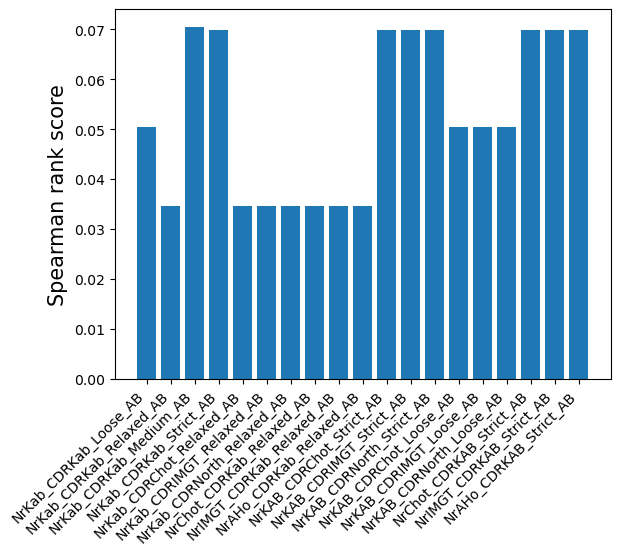

In [25]:
# bar plot all settings
plt.bar(ranked_score_table['dataframe'], ranked_score_table['spearmanr'])
plt.xticks(rotation=45, ha="right")
plt.ylabel('Spearman rank score', size=15)